# **U.S. Airline Flight Delay Analysis**

**Team Members:** Jenny Chen(jc13736), Sanjana Kosuru(sk11582), Tianqi Zhen(tz2949)  
**Course:** CS-GY 6513-C Big Data  
**Semester:** Spring 2026

This project analyzes large-scale U.S. airline delay data to uncover key patterns and factors, and generate insights that can support future flight delay prediction.

The project consists of three stages:
1. **Data Engineering**: Clean and prepare large-scale airline data
2. **Data Analysis**: Identify key delay patterns and insights
3. **Prediction Modeling**: Build models to predict flight delays

---

## Technologies Used

This project leverages a modern big data and analytics stack to process, analyze, and model large-scale airline data:

- **Apache Spark (PySpark)** for distributed data processing and scalable computation  
- **Spark SQL** for efficient querying and aggregation of structured data  
- **Python (Pandas, NumPy)** for data preprocessing and feature engineering  
- **Matplotlib** for data visualization and exploratory analysis  
- **Spark ML** for building and evaluating machine learning models  
- **Google Colab** as the cloud-based development environment  

---

# **Data Engineering**

## Environment Setup

PySpark is used for large-scale data processing, and Google Drive is used for persistent data storage in Colab.

In [3]:
!pip install pyspark -q

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Raw Data Extraction

The raw dataset is stored as a compressed outer ZIP archive.  
After extracting the outer archive, we obtain a folder containing monthly ZIP files for the selected year.  
These monthly ZIP files are then extracted into a separate directory for further processing.

In [5]:
import os
import zipfile
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lpad, floor

outer_zip_path = "/content/drive/MyDrive/BigDataProject/BTS_Data_2024.zip"
outer_extract_dir = "/content/drive/MyDrive/BigDataProject/bts_data"
if not os.path.exists(outer_extract_dir):
    os.makedirs(outer_extract_dir, exist_ok=True)

    # Extract outer zip
    with zipfile.ZipFile(outer_zip_path, 'r') as zip_ref:
        zip_ref.extractall(outer_extract_dir)

    print("Extracted for the first time.")
else:
    print("Already extracted. Skipping extraction.")

print("Contents of outer_extract_dir:")
for item in os.listdir(outer_extract_dir):
    print(item)

Already extracted. Skipping extraction.
Contents of outer_extract_dir:
BTS_Data_2024
__MACOSX
extracted_monthly


In [6]:
for root, dirs, files in os.walk(outer_extract_dir):
    print("Folder:", root)
    print("Files:", files)
    print("-----")

Folder: /content/drive/MyDrive/BigDataProject/bts_data
Files: []
-----
Folder: /content/drive/MyDrive/BigDataProject/bts_data/BTS_Data_2024
Files: ['On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_6 2.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_9.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_8.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_6.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_7.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_5.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_4.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_12.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_1.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_3.zip', 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_11.zip', 'On_Time_Reporting_Carrier_On_Time_Performanc

In [7]:
# Folder that contains the monthly zip files
monthly_zip_dir = outer_extract_dir + "/BTS_Data_2024"

# Folder to extract all monthly zips
monthly_extract_dir = outer_extract_dir + "/extracted_monthly"
os.makedirs(monthly_extract_dir, exist_ok=True)

# Collect all inner zip files, and ignore duplicate files like "... 2.zip"
monthly_zip_files = [
    f for f in os.listdir(monthly_zip_dir)
    if f.endswith(".zip") and " 2" not in f
]

print("Monthly zip files to process:", len(monthly_zip_files))

for f in monthly_zip_files:
    print(f)

# Extract each monthly zip into its own subfolder
for zip_file in monthly_zip_files:
    zip_path = os.path.join(monthly_zip_dir, zip_file)

    folder_name = os.path.splitext(zip_file)[0].replace(" ", "_")
    target_dir = os.path.join(monthly_extract_dir, folder_name)

    # Skip if already extracted
    if os.path.exists(target_dir) and len(os.listdir(target_dir)) > 0:
        print(f"Already extracted: {zip_file}")
        continue

    os.makedirs(target_dir, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(target_dir)
        print(f"Extracted: {zip_file}")
    except Exception as e:
        print(f"Failed to extract {zip_file}: {e}")

Monthly zip files to process: 12
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_9.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_8.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_6.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_7.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_5.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_4.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_12.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_1.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_3.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_11.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_10.zip
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_2.zip
Already extracted: On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_9.zip
Already extracted: On_Time_Reportin

## File Discovery and Validation

After extracting the monthly archives, we recursively scan the extracted directory and identify valid CSV files only.  
System-generated files such as `__MACOSX` artifacts are excluded to avoid loading invalid data into Spark.

In [8]:
csv_files = []

for root, dirs, files in os.walk(monthly_extract_dir):
    for file in files:
        full_path = os.path.join(root, file)
        if file.endswith(".csv") and "__MACOSX" not in full_path and "/._" not in full_path:
            csv_files.append(full_path)

csv_files = sorted(csv_files)

print("Valid CSV files found:", len(csv_files))
print("First few CSV files:")
for f in csv_files[:5]:
    print(f)

Valid CSV files found: 12
First few CSV files:
/content/drive/MyDrive/BigDataProject/bts_data/extracted_monthly/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_1/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_1/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv
/content/drive/MyDrive/BigDataProject/bts_data/extracted_monthly/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_10/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_10/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_10.csv
/content/drive/MyDrive/BigDataProject/bts_data/extracted_monthly/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_11/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_11/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_11.csv
/content/drive/MyDrive/BigDataProject/bts_data/extracted_monthly/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_12/On_Time_

## Spark Data Ingestion

The cleaned CSV files are loaded into a Spark DataFrame using schema inference.

This enables scalable processing of millions of flight records for further analysis.

In [9]:
spark = SparkSession.builder \
    .appName("BTS_Airline_Delay_Cleaning") \
    .getOrCreate()

print("Spark session is ready.")

Spark session is ready.


In [11]:
df = spark.read.csv(
    csv_files,
    header=True,
    inferSchema=True
)

# Check dataset size
print("Row count:", df.count())

# Preview data
df.show(5, truncate=False)

Row count: 7070784
+----+-------+-----+----------+---------+----------+-----------------+------------------------+---------------------------+-----------+-------------------------------+---------------+------------------+------------------+------+--------------+-----------+---------------+---------------+---------+-------------+----------------+----------------+----+------------+---------+-------------+-------------+-------+----------+-------+--------+---------------+--------+--------------------+----------+-------+---------+--------+------+----------+-------+--------+---------------+--------+------------------+----------+---------+----------------+--------+--------------+-----------------+-------+-------+--------+-------------+------------+------------+--------+-------------+-----------------+------------+-------------+---------------+------------------+--------------+--------------------+-----------+-----------+-----------+-------------+----------------+------------+--------------+--

In [12]:
# Print schema
df.printSchema()


root
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- FlightDate: date (nullable = true)
 |-- Reporting_Airline: string (nullable = true)
 |-- DOT_ID_Reporting_Airline: integer (nullable = true)
 |-- IATA_CODE_Reporting_Airline: string (nullable = true)
 |-- Tail_Number: string (nullable = true)
 |-- Flight_Number_Reporting_Airline: integer (nullable = true)
 |-- OriginAirportID: integer (nullable = true)
 |-- OriginAirportSeqID: integer (nullable = true)
 |-- OriginCityMarketID: integer (nullable = true)
 |-- Origin: string (nullable = true)
 |-- OriginCityName: string (nullable = true)
 |-- OriginState: string (nullable = true)
 |-- OriginStateFips: integer (nullable = true)
 |-- OriginStateName: string (nullable = true)
 |-- OriginWac: integer (nullable = true)
 |-- DestAirportID: integer (nullable = true)
 |-- DestAirportSeqID: 

In [13]:
# Explore dataset structure
columns = df.columns
print("Number of columns in the original dataset:", len(columns))
print("Column names:", columns)

Number of columns in the original dataset: 110
Column names: ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'DOT_ID_Reporting_Airline', 'IATA_CODE_Reporting_Airline', 'Tail_Number', 'Flight_Number_Reporting_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'Cancelled', 'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Flights', 'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'Securit

## Core Column Selection

The raw airline dataset contains many fields.  
To keep the analysis focused and efficient, we select a subset of core columns related to:

- flight date and schedule
- airline identity
- origin and destination airports
- departure and arrival delays
- cancellation and diversion indicators
- elapsed time and distance
- detailed delay causes

In [14]:
core_columns = [
    "Year", "Quarter", "Month", "DayofMonth", "DayOfWeek",
    "FlightDate",

    "Reporting_Airline",

    "Origin", "OriginCityName", "OriginState",
    "Dest", "DestCityName", "DestState",

    "CRSDepTime", "DepTime", "DepDelay", "DepDelayMinutes",
    "CRSArrTime", "ArrTime", "ArrDelay", "ArrDelayMinutes",

    "Cancelled",  "Diverted",

    "CRSElapsedTime", "ActualElapsedTime", "AirTime", "Distance",

    "CarrierDelay", "WeatherDelay", "NASDelay",
    "SecurityDelay", "LateAircraftDelay"
]

df_core = df.select(*core_columns)
print("Selected columns:", len(df_core.columns))
print(df_core.columns)


Selected columns: 32
['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'Origin', 'OriginCityName', 'OriginState', 'Dest', 'DestCityName', 'DestState', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'Cancelled', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']


In [15]:
print("Sample data:")
df_core.show(5, truncate=False)

Sample data:
+----+-------+-----+----------+---------+----------+-----------------+------+--------------+-----------+----+------------+---------+----------+-------+--------+---------------+----------+-------+--------+---------------+---------+--------+--------------+-----------------+-------+--------+------------+------------+--------+-------------+-----------------+
|Year|Quarter|Month|DayofMonth|DayOfWeek|FlightDate|Reporting_Airline|Origin|OriginCityName|OriginState|Dest|DestCityName|DestState|CRSDepTime|DepTime|DepDelay|DepDelayMinutes|CRSArrTime|ArrTime|ArrDelay|ArrDelayMinutes|Cancelled|Diverted|CRSElapsedTime|ActualElapsedTime|AirTime|Distance|CarrierDelay|WeatherDelay|NASDelay|SecurityDelay|LateAircraftDelay|
+----+-------+-----+----------+---------+----------+-----------------+------+--------------+-----------+----+------------+---------+----------+-------+--------+---------------+----------+-------+--------+---------------+---------+--------+--------------+-----------------+-

## Data Cleaning

The data cleaning process removes incomplete and invalid records and standardizes important delay-related fields.

The cleaning steps include:

- removing rows with critical missing values
- excluding cancelled flights from standard delay analysis
- filtering out invalid distance and departure hour values
- replacing missing delay minutes with zero
- standardizing delay cause columns

In [16]:
# Create delay indicators and basic time features
df_clean = df_core \
    .withColumn("is_cancelled", col("Cancelled").cast("int")) \
    .withColumn("is_diverted", col("Diverted").cast("int")) \
    .withColumn("is_dep_delayed", when(col("DepDelayMinutes") > 15, 1).otherwise(0)) \
    .withColumn("is_arr_delayed", when(col("ArrDelayMinutes") > 15, 1).otherwise(0)) \
    .withColumn("CRSDepTime_PADDED", lpad(col("CRSDepTime").cast("string"), 4, "0")) \
    .withColumn("dep_hour", floor(col("CRSDepTime_PADDED").substr(1, 2).cast("int")))

In [17]:
# Create seasonal feature
df_clean = df_clean.withColumn(
    "season",
    when(col("Month").isin(12, 1, 2), "Winter")
    .when(col("Month").isin(3, 4, 5), "Spring")
    .when(col("Month").isin(6, 7, 8), "Summer")
    .otherwise("Fall")
)

In [18]:
# Remove rows with critical missing values
df_clean = df_clean.dropna(subset=[
    "FlightDate", "Reporting_Airline", "Origin", "Dest",
    "CRSDepTime", "CRSArrTime", "Distance"
])

# Filter invalid records
df_clean = df_clean.filter(col("is_cancelled") == 0)
df_clean = df_clean.filter(col("Distance") > 0)
df_clean = df_clean.filter((col("dep_hour") >= 0) & (col("dep_hour") <= 23))

In [19]:
# Replace missing delay values with 0
df_clean = df_clean.withColumn(
    "DepDelayMinutes",
    when(col("DepDelayMinutes").isNull(), 0).otherwise(col("DepDelayMinutes"))
)

df_clean = df_clean.withColumn(
    "ArrDelayMinutes",
    when(col("ArrDelayMinutes").isNull(), 0).otherwise(col("ArrDelayMinutes"))
)

delay_cols = ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]

for c in delay_cols:
    df_clean = df_clean.withColumn(
        c,
        when(col(c).isNull(), 0).otherwise(col(c))
    )

In [20]:
# Create additional features
df_clean = df_clean.withColumn(
    "is_weekend",
    when(col("DayOfWeek").isin(6, 7), 1).otherwise(0)
)

df_clean = df_clean.withColumn(
    "dep_period",
    when((col("dep_hour") >= 5) & (col("dep_hour") < 12), "Morning")
    .when((col("dep_hour") >= 12) & (col("dep_hour") < 17), "Afternoon")
    .when((col("dep_hour") >= 17) & (col("dep_hour") < 21), "Evening")
    .otherwise("Night")
)

df_clean = df_clean.withColumn(
    "is_long_flight",
    when(col("Distance") >= 1500, 1).otherwise(0)
)

In [21]:
df_clean.createOrReplaceTempView("airline_data")
print("Temporary SQL view 'airline_data' is ready.")

Temporary SQL view 'airline_data' is ready.


## Cleaned Data Validation

After cleaning, we validate the dataset by checking the final size, sample records, and missing values in key columns.

In [22]:
print("Cleaned row count:", df_clean.count())
print("Cleaned column count:", len(df_clean.columns))

Cleaned row count: 6969618
Cleaned column count: 42


In [23]:
print("Row before cleaning:", df.count())
print("Row after cleaning:", df_clean.count())

Row before cleaning: 7070784
Row after cleaning: 6969618


In [24]:
print("Column before cleaning:", len(df.columns))
print("Column after cleaning:", len(df_clean.columns))

Column before cleaning: 110
Column after cleaning: 42


In [25]:
print("Columns in cleaned dataset:")
print(df_clean.columns)

Columns in cleaned dataset:
['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'Origin', 'OriginCityName', 'OriginState', 'Dest', 'DestCityName', 'DestState', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'Cancelled', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'is_cancelled', 'is_diverted', 'is_dep_delayed', 'is_arr_delayed', 'CRSDepTime_PADDED', 'dep_hour', 'season', 'is_weekend', 'dep_period', 'is_long_flight']


In [26]:
print("Sample cleaned data:")
df_clean.show(5, truncate=False)

Sample cleaned data:
+----+-------+-----+----------+---------+----------+-----------------+------+--------------+-----------+----+------------+---------+----------+-------+--------+---------------+----------+-------+--------+---------------+---------+--------+--------------+-----------------+-------+--------+------------+------------+--------+-------------+-----------------+------------+-----------+--------------+--------------+-----------------+--------+------+----------+----------+--------------+
|Year|Quarter|Month|DayofMonth|DayOfWeek|FlightDate|Reporting_Airline|Origin|OriginCityName|OriginState|Dest|DestCityName|DestState|CRSDepTime|DepTime|DepDelay|DepDelayMinutes|CRSArrTime|ArrTime|ArrDelay|ArrDelayMinutes|Cancelled|Diverted|CRSElapsedTime|ActualElapsedTime|AirTime|Distance|CarrierDelay|WeatherDelay|NASDelay|SecurityDelay|LateAircraftDelay|is_cancelled|is_diverted|is_dep_delayed|is_arr_delayed|CRSDepTime_PADDED|dep_hour|season|is_weekend|dep_period|is_long_flight|
+----+-------

In [27]:
# Show some important columns
df_clean.select(
    "Year", "Month", "DayOfWeek",
    "Reporting_Airline",
    "Origin", "Dest",
    "CRSDepTime", "dep_hour",
    "DepDelayMinutes", "ArrDelayMinutes",
    "is_dep_delayed", "is_arr_delayed",
    "is_cancelled", "is_diverted",
    "season"
).show(10, False)

+----+-----+---------+-----------------+------+----+----------+--------+---------------+---------------+--------------+--------------+------------+-----------+------+
|Year|Month|DayOfWeek|Reporting_Airline|Origin|Dest|CRSDepTime|dep_hour|DepDelayMinutes|ArrDelayMinutes|is_dep_delayed|is_arr_delayed|is_cancelled|is_diverted|season|
+----+-----+---------+-----------------+------+----+----------+--------+---------------+---------------+--------------+--------------+------------+-----------+------+
|2024|1    |1        |9E               |LGA   |OMA |856       |8       |0.0            |0.0            |0             |0             |0           |0          |Winter|
|2024|1    |2        |9E               |LGA   |OMA |856       |8       |0.0            |0.0            |0             |0             |0           |0          |Winter|
|2024|1    |3        |9E               |LGA   |OMA |856       |8       |0.0            |0.0            |0             |0             |0           |0          |Winter

In [28]:
# Check missing values in key columns
from pyspark.sql.functions import sum as spark_sum

df_clean.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in ["Origin", "Dest", "Distance", "DepDelayMinutes", "ArrDelayMinutes"]
]).show()

+------+----+--------+---------------+---------------+
|Origin|Dest|Distance|DepDelayMinutes|ArrDelayMinutes|
+------+----+--------+---------------+---------------+
|     0|   0|       0|              0|              0|
+------+----+--------+---------------+---------------+



# **Data Analysis**

In this section, we perform exploratory data analysis to understand patterns in flight delays.

We use **Spark SQL** and **PySpark DataFrame** to aggregate and analyze large-scale airline data efficiently. For visualization, we use **Matplotlib** to present key findings.

The main goals of this section are:
- identify airlines and airports with the highest delays
- analyze the main causes of delays
- examine how delays vary over time (day, month, time of day)
- explore the relationship between flight distance and delay

These analyses provide insights into delay behavior and help support further predictive modeling.



In [29]:
from pyspark.sql.functions import col, avg, sum as spark_sum, count, when, round, desc
import matplotlib.pyplot as plt

## 1 Airline Performance Analysis
- What is the average delay time for each airline?
- Which airlines have the highest delay times (show Top 10)?


In [30]:
airline_delay = df_clean.groupBy("Reporting_Airline") \
    .agg(round(avg("DepDelayMinutes"), 2).alias("avg_delay")) \
    .orderBy("avg_delay", ascending=False)

# The table below shows the top airlines ranked by average departure delay.
airline_delay.show(10)


+-----------------+---------+
|Reporting_Airline|avg_delay|
+-----------------+---------+
|               F9|    24.17|
|               AA|    23.49|
|               B6|    21.68|
|               OH|    19.43|
|               G4|    19.37|
|               NK|     18.8|
|               OO|    16.42|
|               UA|    15.56|
|               DL|    14.01|
|               WN|    13.71|
+-----------------+---------+
only showing top 10 rows


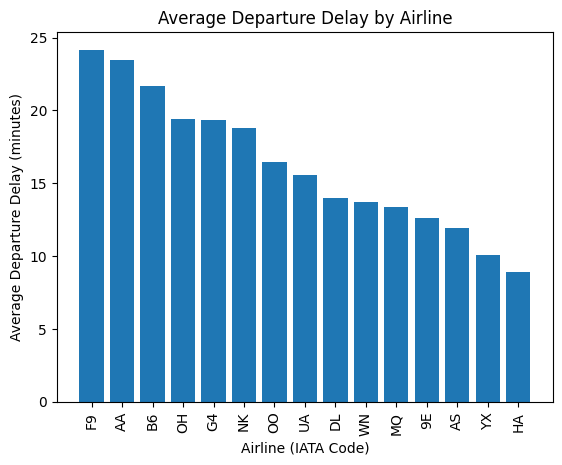

In [31]:
# Visualize average departure delay for each airline
airline_pd_all = airline_delay.toPandas()

plt.figure()
plt.bar(airline_pd_all["Reporting_Airline"], airline_pd_all["avg_delay"])

plt.xlabel("Airline (IATA Code)")
plt.ylabel("Average Departure Delay (minutes)")
plt.title("Average Departure Delay by Airline")

plt.xticks(rotation=90)
plt.show()

The results show that average departure delay differs across airlines. Airlines like F9 and AA have higher delays, while airlines such as WN and DL perform better with lower average delays. This suggests that airline choice can impact the likelihood of experiencing delays.

## 2. Airport Analysis

- Which airports experience the most delays (Top 10)?
- Which airports experience the highest flight volume (Top 10)?

In [32]:
# Count the number of delayed flights for each origin airport
airport_delay = df_clean.filter(col("DepDelayMinutes") > 0) \
    .groupBy("Origin") \
    .agg(count("*").alias("delay_count")) \
    .orderBy("delay_count", ascending=False)

airport_delay.show(10)

+------+-----------+
|Origin|delay_count|
+------+-----------+
|   DEN|     138055|
|   DFW|     135243|
|   ATL|     120438|
|   ORD|     113048|
|   CLT|      94881|
|   LAS|      82762|
|   PHX|      76526|
|   MCO|      69560|
|   SEA|      66475|
|   LAX|      66303|
+------+-----------+
only showing top 10 rows


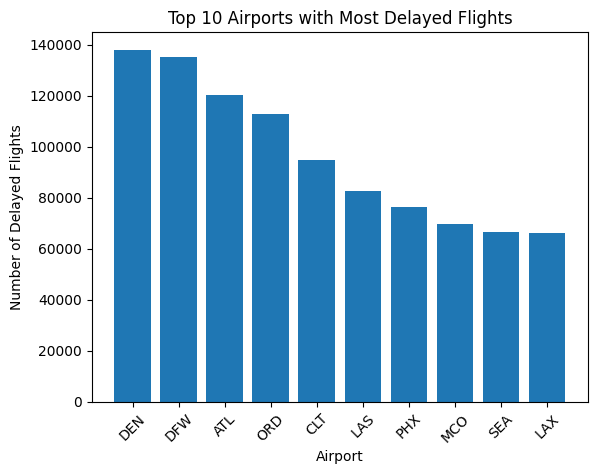

In [33]:
# Visualize the top 10 airports with the most delayed flights
airport_delay_pd = airport_delay.limit(10).toPandas()

plt.figure()
plt.bar(airport_delay_pd["Origin"], airport_delay_pd["delay_count"])

plt.xlabel("Airport")
plt.ylabel("Number of Delayed Flights")
plt.title("Top 10 Airports with Most Delayed Flights")

plt.xticks(rotation=45)
plt.show()

In [34]:
# Count total flight volume for each origin airport
airport_volume = df_clean.groupBy("Origin") \
    .agg(count("*").alias("flight_count")) \
    .orderBy("flight_count", ascending=False)

airport_volume.show(10)

+------+------------+
|Origin|flight_count|
+------+------------+
|   ATL|      334706|
|   DFW|      308078|
|   DEN|      305201|
|   ORD|      280821|
|   CLT|      211657|
|   PHX|      192685|
|   LAX|      191946|
|   LAS|      186526|
|   SEA|      162268|
|   MCO|      157163|
+------+------------+
only showing top 10 rows


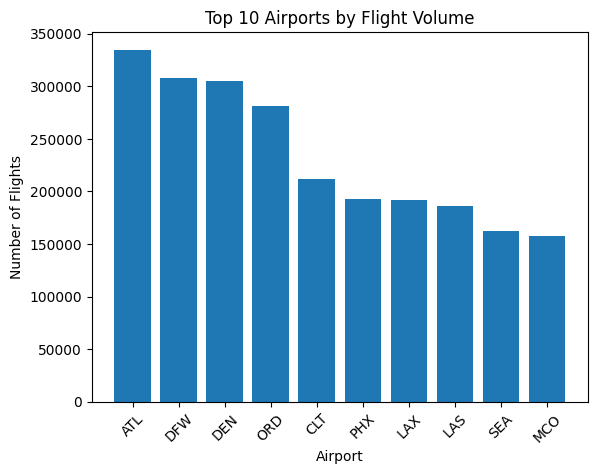

In [35]:
# Visualize the top 10 airports with the highest flight volume
airport_volume_pd = airport_volume.limit(10).toPandas()

plt.figure()
plt.bar(airport_volume_pd["Origin"], airport_volume_pd["flight_count"])

plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.title("Top 10 Airports by Flight Volume")

plt.xticks(rotation=45)
plt.show()

Airports such as DEN, DFW, and ATL have both the highest number of delays and the highest flight volume. This shows that delays are mainly concentrated at busy airports. In general, higher flight volume leads to more delays, likely due to congestion and heavy traffic.

## 3. Delay Cause Analysis
- What are the most common causes of delays?


In [36]:
# Calculate total delay minutes for each delay cause to measure overall impact
from pyspark.sql.functions import sum as spark_sum

delay_cause = df_clean.agg(
    spark_sum("CarrierDelay").alias("Carrier"),
    spark_sum("WeatherDelay").alias("Weather"),
    spark_sum("NASDelay").alias("NAS"),
    spark_sum("SecurityDelay").alias("Security"),
    spark_sum("LateAircraftDelay").alias("Late Aircraft")
)

delay_cause.show()

+-----------+---------+-----------+--------+-------------+
|    Carrier|  Weather|        NAS|Security|Late Aircraft|
+-----------+---------+-----------+--------+-------------+
|3.6621557E7|6267029.0|2.0242996E7|183950.0|  4.3136577E7|
+-----------+---------+-----------+--------+-------------+



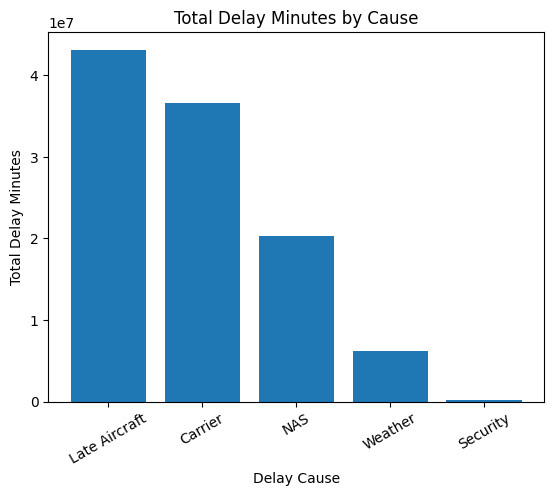

In [37]:
# Visualize total delay minutes by each delay cause

# Convert result to Pandas, reshape, sort, and visualize delay causes
cause_pd = delay_cause.toPandas().T.reset_index()
cause_pd.columns = ["Cause", "TotalDelay"]

# Sort by total delay for clearer comparison
cause_pd = cause_pd.sort_values(by="TotalDelay", ascending=False)

# Convert to integer for better readability
cause_pd["TotalDelay"] = cause_pd["TotalDelay"].astype(int)

plt.figure()
plt.bar(cause_pd["Cause"], cause_pd["TotalDelay"])

plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")
plt.title("Total Delay Minutes by Cause")

plt.xticks(rotation=30)
plt.show()

The results show that Late Aircraft and Carrier delays contribute the most to total delay time. This indicates that delays are mainly caused by airline operations and tend to propagate across flights.

In contrast, Weather and Security delays have relatively small impacts, suggesting external factors play a less significant role.

## 4. Temporal Analysis
- How does delay vary by day of the week?
- How does delay vary by month?


In [38]:
# Calculate average delay by day of week
delay_by_day = df_clean.groupBy("DayOfWeek") \
    .agg(round(avg("DepDelayMinutes"), 2).alias("avg_delay")) \
    .orderBy("DayOfWeek")

delay_by_day.show()

+---------+---------+
|DayOfWeek|avg_delay|
+---------+---------+
|        1|    16.76|
|        2|    14.42|
|        3|    14.08|
|        4|    16.21|
|        5|    18.08|
|        6|    15.87|
|        7|    18.56|
+---------+---------+



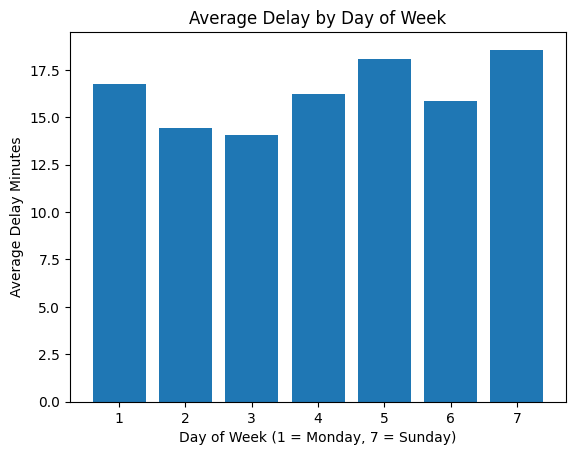

In [39]:
# Visualize average delay by day of week
delay_day_pd = delay_by_day.toPandas()

plt.figure()
plt.bar(delay_day_pd["DayOfWeek"], delay_day_pd["avg_delay"])

plt.xlabel("Day of Week (1 = Monday, 7 = Sunday)")
plt.ylabel("Average Delay Minutes")
plt.title("Average Delay by Day of Week")

plt.show()

In [40]:
# Calculate average delay by month
delay_by_month = df_clean.groupBy("Month") \
    .agg(round(avg("DepDelayMinutes"), 2).alias("avg_delay")) \
    .orderBy("Month")

delay_by_month.show()

+-----+---------+
|Month|avg_delay|
+-----+---------+
|    1|    18.75|
|    2|    11.18|
|    3|    15.68|
|    4|    14.18|
|    5|    20.85|
|    6|    19.69|
|    7|     24.9|
|    8|    18.39|
|    9|    10.56|
|   10|     9.39|
|   11|    10.17|
|   12|    21.18|
+-----+---------+



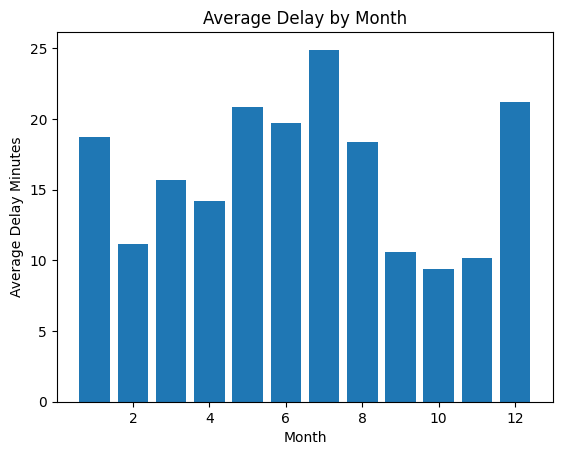

In [41]:
# Visualize average delay by month
delay_month_pd = delay_by_month.toPandas()

plt.figure()
plt.bar(delay_month_pd["Month"], delay_month_pd["avg_delay"])

plt.xlabel("Month")
plt.ylabel("Average Delay Minutes")
plt.title("Average Delay by Month")

plt.show()

Delays show a clear weekly pattern. Mid-week days (Tuesday–Wednesday) have the lowest average delays, while delays increase toward the end of the week, with the highest values on Friday and Sunday. This suggests that higher travel demand and tighter schedules toward weekends lead to more delays.

By month, delays are significantly higher in the summer (June–July) and again in December, while fall months (September–November) have the lowest delays. This indicates that peak travel seasons and heavier traffic likely contribute to increased delays.

## 5. Departure Time Analysis
- How does delay vary by time of day (morning, afternoon, evening, night)?


In [42]:
# Calculate average delay by departure period
delay_by_time = df_clean.groupBy("dep_period") \
    .agg(round(avg("DepDelayMinutes"), 2).alias("avg_delay"))

delay_by_time.show()

+----------+---------+
|dep_period|avg_delay|
+----------+---------+
|   Evening|     23.2|
|   Morning|    10.59|
| Afternoon|    17.79|
|     Night|    22.75|
+----------+---------+



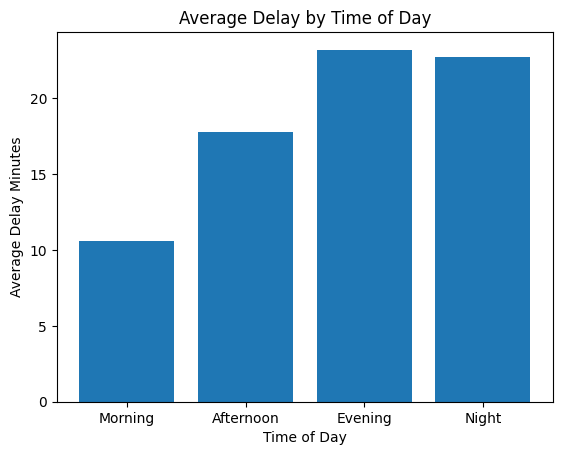

In [43]:
import pandas as pd
# Visualize average delay by time of day (morning, afternoon, evening, night)
delay_time_pd = delay_by_time.toPandas()

# Fix order
order = ["Morning", "Afternoon", "Evening", "Night"]
delay_time_pd["dep_period"] = pd.Categorical(delay_time_pd["dep_period"], categories=order, ordered=True)
delay_time_pd = delay_time_pd.sort_values("dep_period")

plt.figure()
plt.bar(delay_time_pd["dep_period"], delay_time_pd["avg_delay"])

plt.xlabel("Time of Day")
plt.ylabel("Average Delay Minutes")
plt.title("Average Delay by Time of Day")

plt.show()

Delays are lowest in the morning and become higher later in the day. The highest delays occur in the evening and at night.

This suggests that flights later in the day are more likely to be delayed, possibly because delays from earlier flights carry over.

## 6. Distance Analysis
- How does flight distance relate to delay time?


In [44]:
# Create distance categories
from pyspark.sql.functions import when, col, avg, round

df_distance = df_clean.withColumn(
    "distance_group",
    when(col("Distance") < 500, "Short")
    .when((col("Distance") >= 500) & (col("Distance") < 1500), "Medium")
    .otherwise("Long")
)

# Calculate average delay by distance group
delay_by_distance = df_distance.groupBy("distance_group") \
    .agg(round(avg("DepDelayMinutes"), 2).alias("avg_delay"))

delay_by_distance.show()

+--------------+---------+
|distance_group|avg_delay|
+--------------+---------+
|        Medium|    16.96|
|          Long|    16.59|
|         Short|    15.23|
+--------------+---------+



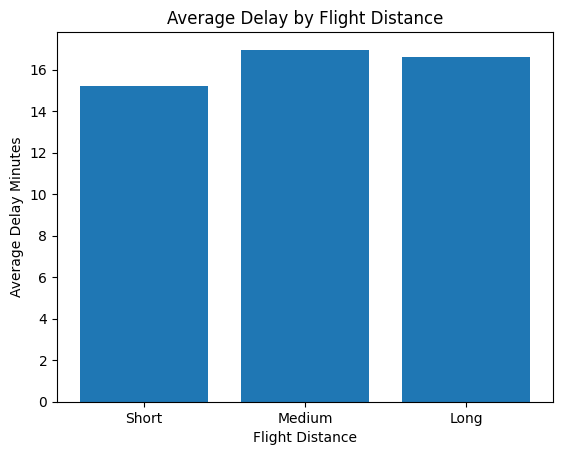

In [45]:
# Visualize delay by distance
delay_dist_pd = delay_by_distance.toPandas()

# Fix order
order = ["Short", "Medium", "Long"]
delay_dist_pd["distance_group"] = pd.Categorical(delay_dist_pd["distance_group"], categories=order, ordered=True)
delay_dist_pd = delay_dist_pd.sort_values("distance_group")

plt.figure()
plt.bar(delay_dist_pd["distance_group"], delay_dist_pd["avg_delay"])

plt.xlabel("Flight Distance")
plt.ylabel("Average Delay Minutes")
plt.title("Average Delay by Flight Distance")

plt.show()

Short flights have slightly lower delays, while medium and long flights show similar delay levels.

This suggests that flight distance does not have a strong impact on delays, and other factors such as airport congestion or scheduling may be more important.

# **Prediction Modeling**

In [46]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when

## Label Definition
A flight is labeled as delayed (`1`) if it arrives more than 15 minutes late,
following the BTS industry standard. Otherwise it is labeled as on-time (`0`).

In [47]:
# Create prediction label: whether the flight arrives more than 15 minutes late
df_model_base = df_clean.withColumn(
    "label",
    when(col("ArrDelayMinutes") > 15, 1).otherwise(0)
)

## Feature Selection
Only pre-flight scheduling and route features are used to avoid data leakage.
Actual delay columns are excluded.

In [48]:
# Select only pre-flight and schedule-based features to avoid data leakage
model_df = df_model_base.filter(
    (col("is_cancelled") == 0) &
    (col("is_diverted") == 0)
).select(
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "OriginState",
    "DestState",
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "dep_hour",
    "season",
    "is_weekend",
    "label"
).dropna()

# Display how many delayed vs non-delayed flights we have
model_df.groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|    1|1432402|
|    0|5519936|
+-----+-------+



## Train/Test Split
The dataset is split 80/20 for training and testing with a fixed random seed.

In [49]:
# Split data into training and testing sets
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

# Check the class distribution before balancing
print("Training set class distribution:")
train_df.groupBy("label").count().show()

print("Test set class distribution:")
test_df.groupBy("label").count().show()

Training set class distribution:
+-----+-------+
|label|  count|
+-----+-------+
|    1|1145458|
|    0|4416350|
+-----+-------+

Test set class distribution:
+-----+-------+
|label|  count|
+-----+-------+
|    1| 286944|
|    0|1103586|
+-----+-------+



## Handling Class Imbalance
The original dataset is imbalanced because most flights are not delayed.  
If we train the model directly on this data, the model may become biased toward predicting the majority class.

To reduce this issue, we undersample the majority class (`label = 0`) in the training set.  
The delayed flights are kept, and only part of the non-delayed flights are sampled.

The test set is not balanced because it should represent the real-world data distribution.

In [50]:
# Separate delayed and non-delayed flights
# label = 1 means delayed, label = 0 means not delayed
delayed_train = train_df.filter(col("label") == 1)
not_delayed_train = train_df.filter(col("label") == 0)

# Count each class in the training set
delayed_count = delayed_train.count()
not_delayed_count = not_delayed_train.count()

# Keep all delayed flights and sample non-delayed flights
# Target ratio: about 1 delayed flight to 2 non-delayed flights
sample_fraction = min((2 * delayed_count) / not_delayed_count, 1.0)

not_delayed_sampled = not_delayed_train.sample(
    withReplacement=False,
    fraction=sample_fraction,
    seed=42
)

# Combine delayed flights with sampled non-delayed flights
train_balanced = delayed_train.union(not_delayed_sampled)

# Check class distribution after balancing
train_balanced.groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|    1|1145458|
|    0|2292725|
+-----+-------+



## Model Pipeline
### Model Pipeline

To prepare the data for machine learning, we build a Spark ML pipeline that converts raw features into a numerical feature vector.

The pipeline consists of the following steps:

1. **Categorical Encoding**
   - Convert categorical variables into numeric indices using `StringIndexer`
   - Apply `OneHotEncoder` to transform them into binary vectors

2. **Feature Assembly**
   - Combine all categorical and numerical features into a single feature vector using `VectorAssembler`

This ensures that all input features are in the correct format for model training.

In [51]:
# Build Spark ML pipeline for categorical encoding and feature assembly

# Categorical features (need encoding)
categorical_cols = [
    "Reporting_Airline",
    "Origin",
    "Dest",
    "OriginState",
    "DestState",
    "season"
]

# Numeric features (already usable)
numeric_cols = [
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "dep_hour",
    "is_weekend"
]

# Convert categorical values into numeric indices
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_index", handleInvalid="keep")
    for c in categorical_cols
]

# Convert indices into one-hot encoded vectors
encoders = [
    OneHotEncoder(inputCol=c + "_index", outputCol=c + "_vec")
    for c in categorical_cols
]

# Combine numeric features + encoded categorical features into one vector
assembler = VectorAssembler(
    inputCols=numeric_cols + [c + "_vec" for c in categorical_cols],
    outputCol="features"
)

## Model Training — Logistic Regression
We train a Logistic Regression classifier as our baseline model with L2 regularization.

In [52]:
# Train Logistic Regression model
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.01
)

# Build full pipeline
lr_pipeline = Pipeline(stages=indexers + encoders + [assembler, lr])

# Train the model
lr_model = lr_pipeline.fit(train_balanced)

# Make predictions
lr_predictions = lr_model.transform(test_df)

# Show sample predictions
lr_predictions.select("label", "prediction", "probability").show(10, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.8621826362103154,0.13781736378968457]|
|0    |0.0       |[0.8609982380897677,0.13900176191023228]|
|0    |0.0       |[0.8451929258295795,0.1548070741704205] |
|0    |0.0       |[0.775673674238441,0.22432632576155898] |
|0    |0.0       |[0.81555685549515,0.18444314450485]     |
|0    |0.0       |[0.6264547177207537,0.3735452822792463] |
|0    |0.0       |[0.8465044845746476,0.15349551542535245]|
|0    |0.0       |[0.8176851109998882,0.18231488900011183]|
|0    |0.0       |[0.6725611057521351,0.3274388942478649] |
|0    |0.0       |[0.7645618928959134,0.23543810710408664]|
+-----+----------+----------------------------------------+
only showing top 10 rows


In [53]:
# Evaluate model performance
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# Calculate evaluation metrics
print("Logistic Regression Results")
print(f"AUC: {auc_evaluator.evaluate(lr_predictions):.2f}")
print(f"Accuracy: {accuracy_evaluator.evaluate(lr_predictions):.2f}")
print(f"F1 Score: {f1_evaluator.evaluate(lr_predictions):.2f}")

Logistic Regression Results
AUC: 0.67
Accuracy: 0.78
F1 Score: 0.74


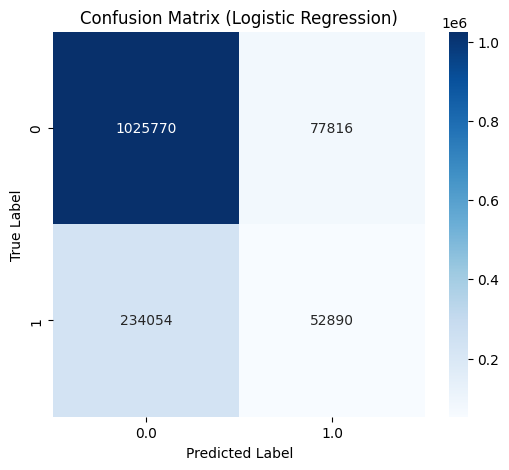

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas DataFrame for visualization
cm_df = lr_predictions.groupBy("label", "prediction").count().toPandas()

# Pivot the table to create a confusion matrix (2x2 format)
cm_pivot = cm_df.pivot(index="label", columns="prediction", values="count")

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_pivot, annot=True, fmt="d", cmap="Blues")

# Add titles and labels
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Display the plot
plt.show()